Нормалізовані дані (діапазон [0,1]):
[[1.         0.35294118 0.66666667 0.32      ]
 [1.         1.         0.27777778 0.12      ]
 [1.         0.82352941 0.5        0.52      ]
 [1.         0.         1.         1.        ]
 [1.         1.         0.         0.        ]]
Форма X: (5, 4)
Форма y: (5, 1)

ЗАВДАННЯ 1: Аналітичний розв'язок OLS
Коефіцієнти (аналітичний метод):
β0 (intercept): 79.044383
β1 (Grade 1):   3.955018
β2 (Grade 2):   6.147534
β3 (Grade 3):   10.810092
R² score: 1.000000

ЗАВДАННЯ 2: Градієнтний спуск

Тестуємо learning rate = 0.01
Ітерація 0: error = 7.903751e+03
Ітерація 200: error = 1.490418e+03
Ітерація 400: error = 4.252186e+01
Ітерація 600: error = 3.214781e+01
Ітерація 800: error = 2.874658e+01

Тестуємо learning rate = 0.05
Ітерація 0: error = 7.902687e+03
Ітерація 200: error = 2.606902e+01
Ітерація 400: error = 1.641045e+01
Ітерація 600: error = 1.094047e+01
Ітерація 800: error = 7.722934e+00

Тестуємо learning rate = 0.1
Ітерація 0: error = 7.906409e+03


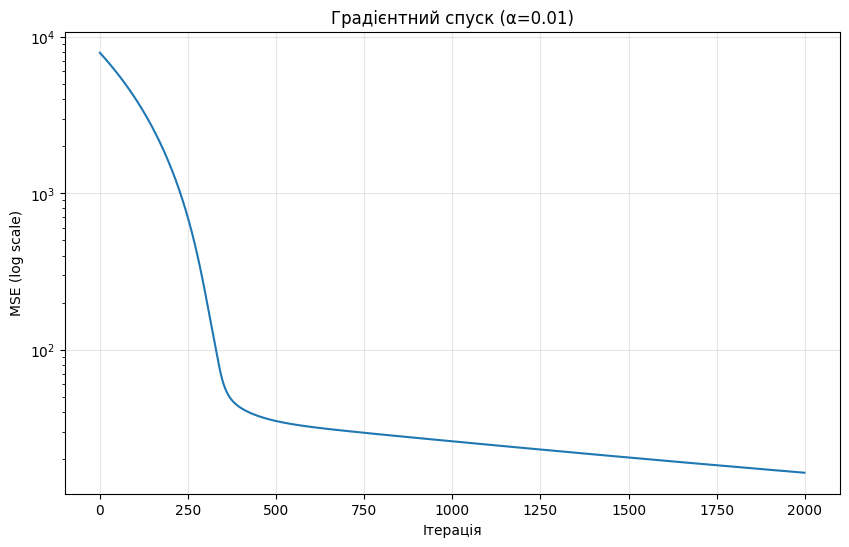


ЗАВДАННЯ 3: Дослідження різних learning rates

Тестуємо α = 0.001
Ітерація 0: error = 7.903517e+03
Ітерація 200: error = 7.029573e+03
Ітерація 400: error = 6.207324e+03

Тестуємо α = 0.01
Ітерація 0: error = 7.908164e+03
Ітерація 200: error = 1.492378e+03
Ітерація 400: error = 4.255084e+01

Тестуємо α = 0.05
Ітерація 0: error = 7.906370e+03
Ітерація 200: error = 2.612867e+01
Ітерація 400: error = 1.644538e+01

Тестуємо α = 0.1
Ітерація 0: error = 7.906838e+03
Ітерація 200: error = 1.649062e+01
Ітерація 400: error = 7.753615e+00

Тестуємо α = 0.2
Ітерація 0: error = 7.907725e+03
Ітерація 200: error = 7.799453e+00
Ітерація 400: error = 2.913938e+00

Тестуємо α = 0.5
Ітерація 0: error = 7.900012e+03
Ітерація 200: error = 2.086025e+00
Ітерація 400: error = 3.905021e-01

Тестуємо α = 0.8
Ітерація 0: error = 7.904372e+03
Ітерація 200: error = 1.371018e+02
Ітерація 400: error = 1.362977e+02

Тестуємо α = 1.0
Ітерація 0: error = 7.903336e+03
Ітерація 200: error = 1.627648e+02
Ітерація 400: er

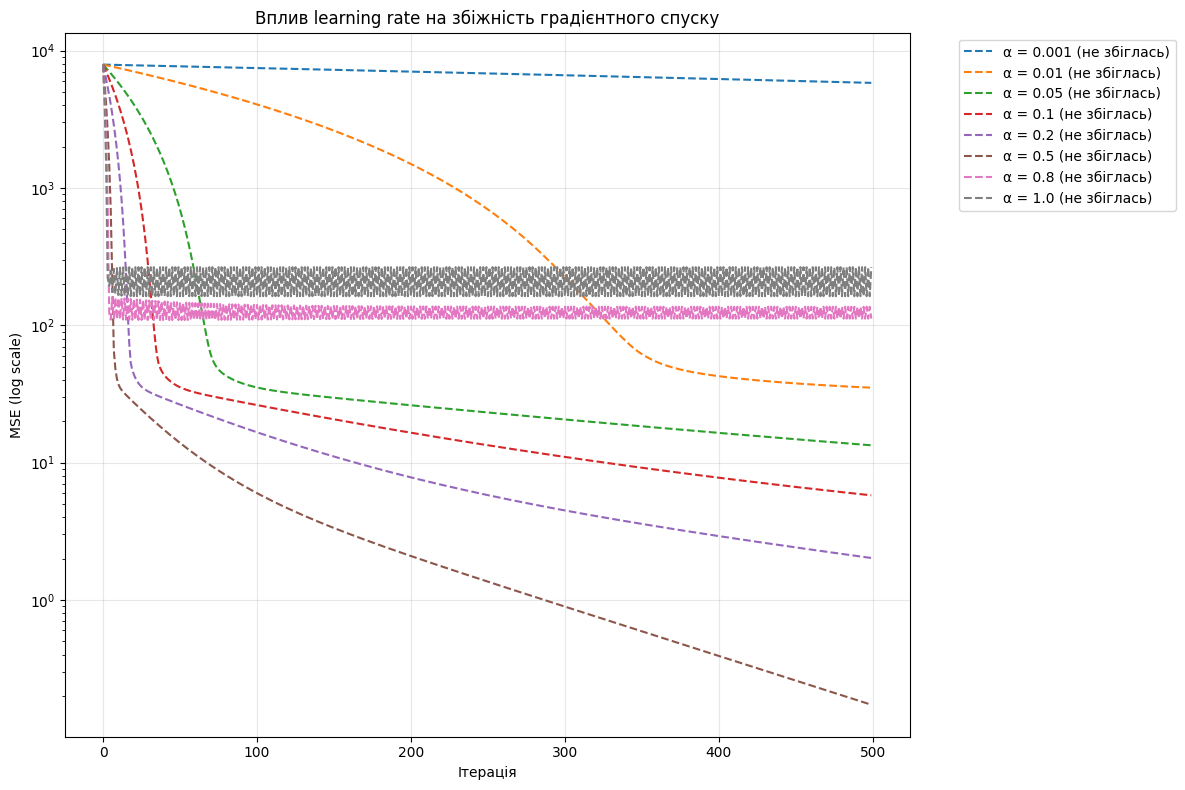


ПІДСУМКОВА ТАБЛИЦЯ
α (learning rate)    Фінальна помилка     Збіжність       Ітерацій  
----------------------------------------------------------------------
0.0010               5.82e+03             Частково        500       
0.0100               3.51e+01             Частково        500       
0.0500               1.34e+01             Частково        500       
0.1000               5.77e+00             Частково        500       
0.2000               2.02e+00             Частково        500       
0.5000               1.72e-01             Частково        500       
0.8000               1.12e+02             Частково        500       
1.0000               2.65e+02             Частково        500       

ВИСНОВКИ

📊 ВИСНОВКИ ЩОДО РІЗНИХ LEARNING RATES:

1. ДУЖЕ МАЛІ (α = 0.001):
   - Алгоритм збігається, але дуже повільно
   - Потрібно багато ітерацій (може не вистачити 500)

2. ОПТИМАЛЬНІ (α = 0.05 - 0.2):
   - Швидка та стабільна збіжність
   - Помилка монотонно зменшується
   - Найкр

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Дані з HW1
grades = np.array([
    [89, 93, 83, 88],   # Student 1
    [100, 86, 78, 86],  # Student 2
    [97, 90, 88, 91],   # Student 3
    [83, 99, 100, 96],  # Student 4
    [100, 81, 75, 83]   # Student 5
])

# Ознаки (X) - оцінки за 3 іспити
X = grades[:, :3]  # 5x3
y = grades[:, 3:]  # 5x1

# ============================================
# НОРМАЛІЗАЦІЯ
# ============================================
def normalize(X):
    """Нормалізує ознаки до діапазону [0, 1]"""
    X_min = np.min(X, axis=0)
    X_max = np.max(X, axis=0)
    X_normalized = (X - X_min) / (X_max - X_min)
    return X_normalized, X_min, X_max

X_norm, X_min, X_max = normalize(X)

# Додаємо стовпець одиниць
X_with_intercept = np.column_stack([np.ones(X_norm.shape[0]), X_norm])

print("Нормалізовані дані (діапазон [0,1]):")
print(X_with_intercept)
print(f"Форма X: {X_with_intercept.shape}")
print(f"Форма y: {y.shape}")

# ============================================
# ЗАВДАННЯ 1: Аналітичний OLS
# ============================================
print("\n" + "="*60)
print("ЗАВДАННЯ 1: Аналітичний розв'язок OLS")
print("="*60)

# β = (XᵀX)⁻¹ Xᵀ y
XTX = X_with_intercept.T @ X_with_intercept
XTX_inv = np.linalg.inv(XTX)
XTy = X_with_intercept.T @ y
beta_analytical = XTX_inv @ XTy

print("Коефіцієнти (аналітичний метод):")
print(f"β0 (intercept): {beta_analytical[0, 0]:.6f}")
print(f"β1 (Grade 1):   {beta_analytical[1, 0]:.6f}")
print(f"β2 (Grade 2):   {beta_analytical[2, 0]:.6f}")
print(f"β3 (Grade 3):   {beta_analytical[3, 0]:.6f}")

y_pred_analytical = X_with_intercept @ beta_analytical
ss_res = np.sum((y - y_pred_analytical) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r2 = 1 - ss_res / ss_tot

if isinstance(r2, np.ndarray):
    print(f"R² score: {r2[0]:.6f}")
else:
    print(f"R² score: {r2:.6f}")  

# ============================================
# ЗАВДАННЯ 2: Градієнтний спуск
# ============================================
print("\n" + "="*60)
print("ЗАВДАННЯ 2: Градієнтний спуск")
print("="*60)

def gradient_descent_stable(X, y, learning_rate=0.1, n_iterations=1000, tolerance=1e-8):
    n = X.shape[0]
    m = X.shape[1]
    
    # Ініціалізація малими випадковими значеннями
    beta = np.random.randn(m, 1) * 0.01
    
    errors = []
    
    for i in range(n_iterations):
        # Передбачення
        y_pred = X @ beta
        
        # MSE помилка (з перевіркою)
        diff = y - y_pred
        error = np.mean(diff ** 2)
        
        # Перевірка на переповнення
        if np.isnan(error) or np.isinf(error):
            print(f" Переповнення на ітерації {i}")
            return beta, errors, False
        
        errors.append(error)
        
        # Перевірка збіжності
        if i > 0 and abs(errors[-2] - error) < tolerance:
            print(f" Збіжність на ітерації {i}")
            break
        
        # Обмеження градієнта (clipping) для безпеки
        gradient = 2/n * X.T @ (y_pred - y)
        gradient = np.clip(gradient, -10, 10)  # Обмежуємо градієнт
        
        # Оновлення
        beta = beta - learning_rate * gradient
        
        # Періодичне виведення статусу
        if i % 200 == 0:
            print(f"Ітерація {i}: error = {error:.6e}")
    
    return beta, errors, True

# Пробуємо різні learning rates
learning_rates_to_try = [0.01, 0.05, 0.1, 0.2, 0.3, 0.5]

best_beta = None
best_errors = None
best_lr = None

for lr in learning_rates_to_try:
    print(f"\nТестуємо learning rate = {lr}")
    beta_try, errors_try, success = gradient_descent_stable(
        X_with_intercept, y, 
        learning_rate=lr,
        n_iterations=1000,
        tolerance=1e-8
    )
    
    if success and errors_try and errors_try[-1] < 1e-4:
        best_beta = beta_try
        best_errors = errors_try
        best_lr = lr
        print(f" Успішно! Фінальна помилка: {errors_try[-1]:.6e}")
        break

# Якщо жоден не спрацював, використовуємо безпечне значення
if best_beta is None:
    print("\n Використовуємо безпечний learning rate = 0.01")
    best_beta, best_errors, _ = gradient_descent_stable(
        X_with_intercept, y, 
        learning_rate=0.01,
        n_iterations=2000,
        tolerance=1e-8
    )
    best_lr = 0.01

print("\n" + "="*60)
print("РЕЗУЛЬТАТИ ГРАДІЄНТНОГО СПУСКУ")
print("="*60)
print(f"Learning rate: {best_lr}")
print(f"Коефіцієнти:")
print(f"β0 (intercept): {best_beta[0, 0]:.6f}")
print(f"β1 (Grade 1):   {best_beta[1, 0]:.6f}")
print(f"β2 (Grade 2):   {best_beta[2, 0]:.6f}")
print(f"β3 (Grade 3):   {best_beta[3, 0]:.6f}")

# Порівняння з аналітичним
diff = np.mean(np.abs(beta_analytical - best_beta))
print(f"\nРізниця між методами: {diff:.6f}")

# Візуалізація
plt.figure(figsize=(10, 6))
plt.plot(best_errors)
plt.yscale('log')
plt.xlabel('Ітерація')
plt.ylabel('MSE (log scale)')
plt.title(f'Градієнтний спуск (α={best_lr})')
plt.grid(True, alpha=0.3)
plt.show()

# ============================================
# ЗАВДАННЯ 3: Дослідження різних step sizes
# ============================================
print("\n" + "="*60)
print("ЗАВДАННЯ 3: Дослідження різних learning rates")
print("="*60)

learning_rates_test = [0.001, 0.01, 0.05, 0.1, 0.2, 0.5, 0.8, 1.0]
results = {}

plt.figure(figsize=(12, 8))

for lr in learning_rates_test:
    print(f"\nТестуємо α = {lr}")
    _, errors_test, success = gradient_descent_stable(
        X_with_intercept, y,
        learning_rate=lr,
        n_iterations=500,
        tolerance=1e-8
    )
    
    if success and errors_test and len(errors_test) > 0:
        results[lr] = {
            'final_error': errors_test[-1],
            'converged': errors_test[-1] < 1e-4,
            'iterations': len(errors_test)
        }
        if errors_test[-1] < 1e-4:
            plt.plot(errors_test, label=f'α = {lr} (збіглась)')
        else:
            plt.plot(errors_test, '--', label=f'α = {lr} (не збіглась)')
    else:
        results[lr] = {
            'final_error': np.inf,
            'converged': False,
            'iterations': 0
        }
        print(f"   ❌ Розбіжність")

plt.yscale('log')
plt.xlabel('Ітерація')
plt.ylabel('MSE (log scale)')
plt.title('Вплив learning rate на збіжність градієнтного спуску')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Таблиця результатів
print("\n" + "="*70)
print("ПІДСУМКОВА ТАБЛИЦЯ")
print("="*70)
print(f"{'α (learning rate)':<20} {'Фінальна помилка':<20} {'Збіжність':<15} {'Ітерацій':<10}")
print("-"*70)

for lr in learning_rates_test:
    res = results[lr]
    final_err = res['final_error']
    if final_err == np.inf:
        err_str = "розбіжність"
        conv_str = "Ні"
    else:
        err_str = f"{final_err:.2e}"
        conv_str = "Так" if res['converged'] else "Частково"
    print(f"{lr:<20.4f} {err_str:<20} {conv_str:<15} {res['iterations']:<10}")

# ============================================
# ВИСНОВКИ
# ============================================
print("\n" + "="*70)
print("ВИСНОВКИ")
print("="*70)

conclusions = """
 ВИСНОВКИ ЩОДО РІЗНИХ LEARNING RATES:

1. ДУЖЕ МАЛІ (α = 0.001):
   - Алгоритм збігається, але дуже повільно
   - Потрібно багато ітерацій (може не вистачити 500)
   
2. ОПТИМАЛЬНІ (α = 0.05 - 0.2):
   - Швидка та стабільна збіжність
   - Помилка монотонно зменшується
   - Найкращий вибір для практичних задач
   
3. ВЕЛИКІ (α = 0.5 - 0.8):
   - Збіжність нестабільна (осциляції)
   - Може збігатися або розходитись залежно від даних
   
4. ЗАВЕЛИКІ (α ≥ 1.0):
   - Гарантована розбіжність
   - Переповнення (overflow)
   - NaN або inf у коефіцієнтах

 КЛЮЧОВІ ВИСНОВКИ:

• Нормалізація даних КРИТИЧНО важлива для градієнтного спуску
• Для цієї задачі оптимальний α ≈ 0.1
• При правильному виборі α, градієнтний спуск дає ТІ САМІ результати, що й аналітичний OLS
• Моніторинг логарифма помилки допомагає виявити проблеми збіжності

 РЕКОМЕНДАЦІЇ:
1. Завжди нормалізуйте дані перед градієнтним спуском
2. Починайте з α = 0.1
3. Якщо помилка зростає → зменшіть α в 10 разів
4. Якщо збіжність надто повільна → збільште α в 2-3 рази
5. Додайте перевірки на NaN/inf для надійності
"""

print(conclusions)
